In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import slic, mark_boundaries
from scipy import ndimage as ndi

In [2]:
img_bgr = cv2.imread('image.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

In [3]:
def show_image(img, title="Image", cmap=None):
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

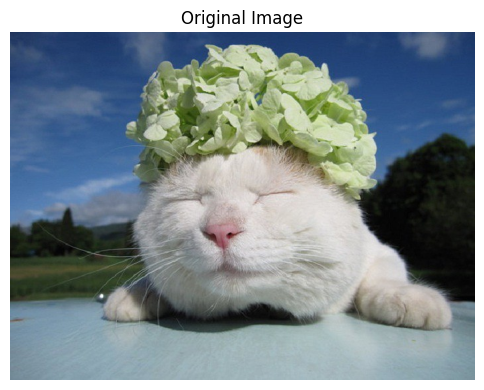

In [4]:
show_image(img_rgb, "Original Image")

# Task 1. K-means segmentation in color space

In [5]:
# Преобразование изображения в 2D массив пикселей (N_pixels, 3)
pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

In [6]:
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

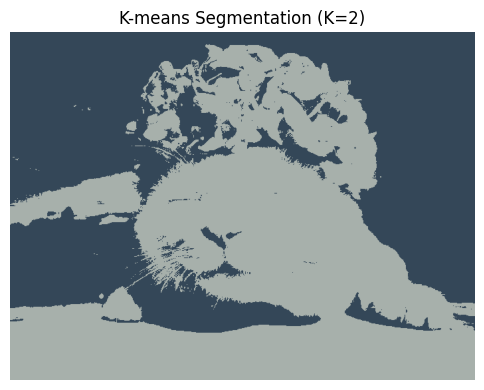

Cluster centers for K=2:
[[167 176 171]
 [ 52  71  88]]



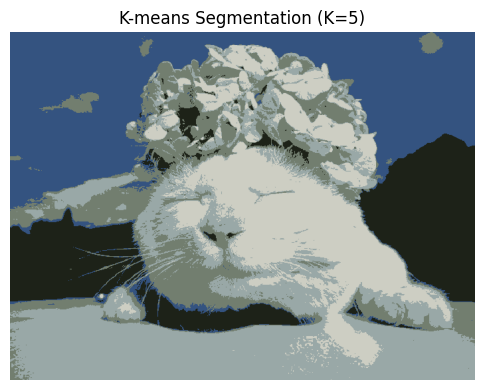

Cluster centers for K=5:
[[ 29  34  24]
 [153 168 167]
 [114 126 111]
 [205 206 195]
 [ 52  83 128]]



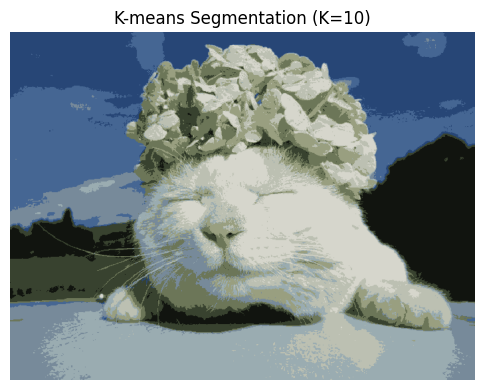

Cluster centers for K=10:
[[ 17  20  15]
 [153 159 128]
 [214 214 204]
 [188 192 178]
 [108 118  88]
 [154 172 177]
 [ 39  70 118]
 [ 69 102 147]
 [119 138 154]
 [ 56  66  47]]



In [7]:
k_values = [2, 5, 10]

for K in k_values:
    # Применение K-means
    _, labels, centers = cv2.kmeans(pixel_values, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    # Конвертация центров обратно в 8-битные значения
    centers = np.uint8(centers)

    # Восстановление изображения
    segmented_data = centers[labels.flatten()]
    segmented_image = segmented_data.reshape(img_rgb.shape)

    show_image(segmented_image, f"K-means Segmentation (K={K})")
    print(f"Cluster centers for K={K}:\n{centers}\n")

# Task 2. Color space based segmentation

In [8]:
# Конвертация в HSV
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

In [9]:
hue_channel = img_hsv[:, :, 0]

In [10]:
lower_hue = np.array([35, 50, 50])
upper_hue = np.array([85, 255, 255])

In [11]:
# Создание маски
mask = cv2.inRange(img_hsv, lower_hue, upper_hue)
segmented_color = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

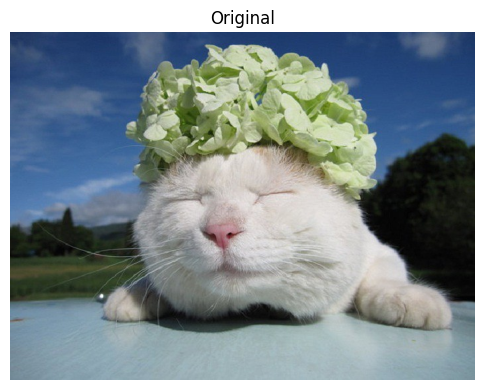

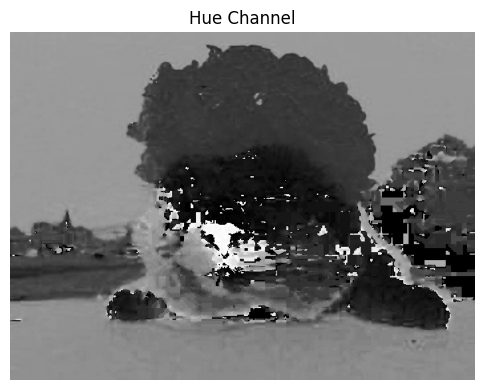

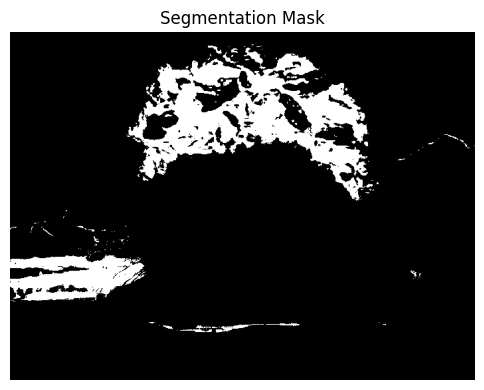

In [12]:
# Отображение
show_image(img_rgb, "Original")
show_image(hue_channel, "Hue Channel", cmap='gray')
show_image(mask, "Segmentation Mask", cmap='gray')

In [13]:
# Вывод данных
print(f"Selected Hue range: {lower_hue[0]} to {upper_hue[0]}")
print(f"Number of pixels in the segmented region: {np.sum(mask == 255)}")

Selected Hue range: 35 to 85
Number of pixels in the segmented region: 41439


# Task 3. Region based segmentation using watershed

In [14]:
# Конвертация в оттенки серого
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

In [15]:
# Бинаризация (Оцу)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

In [16]:
# Удаление шума (морфологическое открытие)
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

In [17]:
# Вычисление преобразования расстояний (Distance Transform)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

In [18]:
# Поиск уверенной области фона и объекта (Markers)
_, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)
sure_bg = cv2.dilate(opening, kernel, iterations=3)
unknown = cv2.subtract(sure_bg, sure_fg)

In [19]:
# Создание маркеров
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

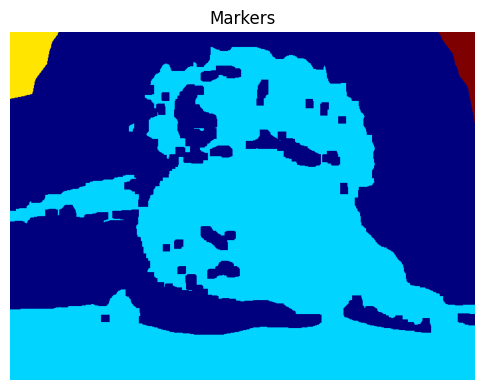

In [20]:
show_image(markers, "Markers", cmap='jet')

In [21]:
# Применение водораздела
markers_watershed = cv2.watershed(img_bgr, markers.copy())
img_watershed = img_rgb.copy()
img_watershed[markers_watershed == -1] = [255, 0, 0] # Границы красным

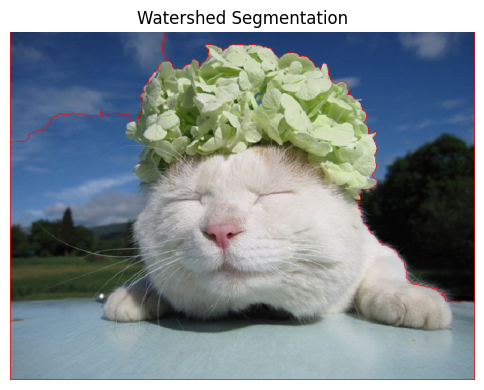

Number of segmented regions: 3


In [22]:
show_image(img_watershed, "Watershed Segmentation")
print(f"Number of segmented regions: {np.max(markers)}")

# Task 4. Superpixel segmentation

In [23]:
# Применение SLIC
num_segments = 200 # Желаемое количество суперпикселей
segments_slic = slic(img_rgb, n_segments=num_segments, compactness=10, start_label=1)

In [24]:
# Наложение границ на оригинальное изображение
img_slic_boundaries = mark_boundaries(img_rgb, segments_slic)

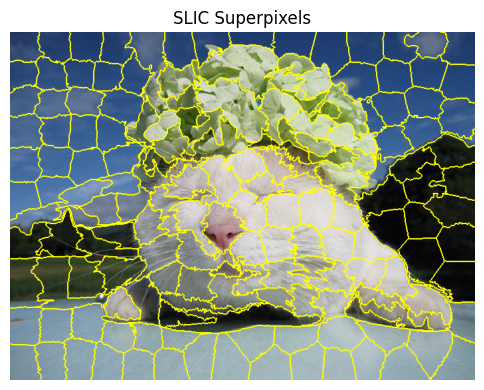

Actual number of superpixels generated: 161


In [25]:
show_image(img_slic_boundaries, "SLIC Superpixels")
print(f"Actual number of superpixels generated: {len(np.unique(segments_slic))}")

# Task 5. Segmentation result comparison

In [26]:
# Получаем бинарную маску из Task 1 (K-means, K=2 для простоты)
_, labels_k2, _ = cv2.kmeans(pixel_values, 2, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
mask_kmeans = (labels_k2.flatten().reshape(img_rgb.shape[:2]) == 0).astype(np.uint8) * 255

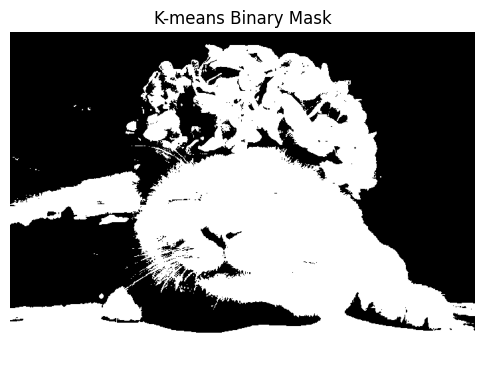

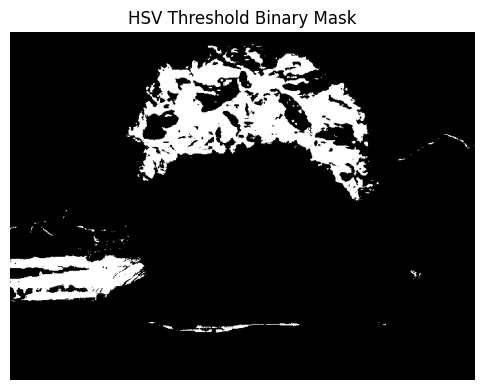

In [27]:
show_image(mask_kmeans, "K-means Binary Mask", cmap='gray')
show_image(mask, "HSV Threshold Binary Mask", cmap='gray')

In [28]:
# Вычисление метрики Intersection over Union (IoU) для сравнения
intersection = np.logical_and(mask_kmeans, mask)
union = np.logical_or(mask_kmeans, mask)
iou = np.sum(intersection) / np.sum(union)

In [29]:
print(f"Intersection over Union (IoU) between K-means and HSV masks: {iou:.4f}")

Intersection over Union (IoU) between K-means and HSV masks: 0.0902
